In [11]:
import pandas as pd

# 1. 设置你的文件路径
# 例如：'BIOGRID-ORGANISM-Homo_sapiens-4.4.231.tab3.txt'
FILE_PATH = r"D:\CodeWork\python\GAR+\数据\去病图数据\去病图数据\protein_protein.csv"

# 2. 你关心的字段名（按你自己的 csv header 改）
TARGET_COLS = [
    "Experimental System",
    "Experimental System Type",
    "Ontology Term Types",
    "Ontology Term Names",
    "Modification",
]

# 3. 读文件
# sep=None + engine="python" 会自动判断是逗号还是制表符
df = pd.read_csv(FILE_PATH, sep=None, engine="python")

print("表头字段：")
print(df.columns.tolist())
print("\n=============================\n")

# 4. 对每个字段输出所有不同取值
for col in TARGET_COLS:
    if col not in df.columns:
        print(f"[跳过] 找不到字段：{col}")
        continue

    print(f"字段：{col}")
    # 去掉缺失值、去重、排序
    values = (
        df[col]
        .dropna()
        .astype(str)
        .unique()
    )

    print(f"  不同取值数量：{len(values)}")
    for v in values:
        print("   -", v)
    print("\n-----------------------------\n")


表头字段：
['#BioGRID Interaction ID', 'Entrez Gene Interactor A', 'Entrez Gene Interactor B', 'BioGRID ID Interactor A', 'BioGRID ID Interactor B', 'Systematic Name Interactor A', 'Systematic Name Interactor B', 'Official Symbol Interactor A', 'Official Symbol Interactor B', 'Synonyms Interactor A', 'Synonyms Interactor B', 'Experimental System', 'Experimental System Type', 'Author', 'Publication Source', 'Organism ID Interactor A', 'Organism ID Interactor B', 'Throughput', 'Score', 'Modification', 'Qualifications', 'SWISS-PROT Accessions Interactor A', 'TREMBL Accessions Interactor A', 'REFSEQ Accessions Interactor A', 'SWISS-PROT Accessions Interactor B', 'TREMBL Accessions Interactor B', 'REFSEQ Accessions Interactor B', 'Ontology Term IDs', 'Ontology Term Names', 'Ontology Term Categories', 'Ontology Term Qualifier IDs', 'Ontology Term Qualifier Names', 'Ontology Term Types', 'Organism Name Interactor A', 'Organism Name Interactor B', 'index_A', 'index_B']


字段：Experimental System
  不同

In [2]:
import pandas as pd
from pathlib import Path

# ====== 1. 配置文件路径 ======
FILE_PATH = Path(r"D:\CodeWork\python\GAR+\数据\去病图数据\去病图数据\protein_protein.csv")   # 改成你的文件名

# import pandas as pd
# from pathlib import Path

# # ============ 1. 配置文件路径 ============
# FILE_PATH = Path("biogrid_ppi.csv")  # 改成你的文件名

# ============ 2. 规则定义 ============

# 2.1 Experimental System：正向
positive_exp_system = {
    "Affinity Capture-MS",
    "Two-hybrid",
    "Affinity Capture-Western",
    "Reconstituted Complex",
    "Proximity Label-MS",
    "Biochemical Activity",
    "Co-purification",
    "Co-fractionation",
    "Co-localization",
    "PCA",
    "Co-crystal Structure",
    "Far Western",
    "Protein-peptide",
    "Protein-RNA",
    "Affinity Capture-RNA",
    "FRET",
    "Affinity Capture-Luminescence",
    "Positive Genetic",
    "Phenotypic Enhancement",
    "Phenotypic Suppression",
    "Dosage Rescue",
    "Synthetic Rescue",
}

# 2.2 Experimental System：负向（遗传互作里典型的负向类型）
negative_exp_system = {
    "Synthetic Lethality",
    "Negative Genetic",
    "Synthetic Growth Defect",
    "Dosage Lethality",
    "Dosage Growth Defect",
}

# 2.3 Modification：正向修饰（通常代表激活或功能增强）
positive_modifications = {
    "Methylation",
    "Ubiquitination",
    "Phosphorylation",
    "Ribosylation",
    "Sumoylation",
    "Acetylation",
    "FAT10ylation",
    "Nedd(Rub1)ylation",
    "Glycosylation",
    "Neddylation",
}

# 2.4 Modification：负向修饰（通常代表去激活/破坏/降解）
negative_modifications = {
    "Deubiquitination",
    "Proteolytic Processing",
    "Desumoylation",
    "Deacetylation",
    "Dephosphorylation",
    "Demethylation",
    "Deneddylation",
}

# 2.5 Ontology Term Types：正向关键词（代表“救回/正常状态”）
positive_onto_type_keywords = ["partial rescue", "wild type"]

# 2.6 Ontology Term Names：负向关键词（扩展 negative 语义的重点）
negative_onto_name_keywords = [
    "abnormal",
    "defect",
    "defective",
    "negative regulation",
    "downregulation",
    "down-regulation",
    "reduced",
    "loss of",
    "decrease",
    "decreased",
    "impaired",
    "resistance",
    "toxicity",
]


# ============ 3. 读入数据 ============
df = pd.read_csv(FILE_PATH, sep=None, engine="python")

required_cols = [
    "Experimental System",
    "Experimental System Type",
    "Modification",
    "Ontology Term Types",
    "Ontology Term Names",
    "index_A",
    "index_B",
]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"缺少必要字段: {c}")


# ============ 4. 打标签函数（带原因） ============
def classify_edge_with_reason(row):
    es = str(row.get("Experimental System", "") or "")
    mod = str(row.get("Modification", "") or "")
    onto_type = str(row.get("Ontology Term Types", "") or "")
    onto_name = str(row.get("Ontology Term Names", "") or "")

    is_pos = False
    is_neg = False
    reasons_pos = []
    reasons_neg = []

    # ---- 4.1 Experimental System ----
    if es in positive_exp_system:
        is_pos = True
        reasons_pos.append(f"exp_system:{es}")
    if es in negative_exp_system:
        is_neg = True
        reasons_neg.append(f"exp_system:{es}")

    # ---- 4.2 Modification ----
    if mod in positive_modifications:
        is_pos = True
        reasons_pos.append(f"mod:{mod}")
    if mod in negative_modifications:
        is_neg = True
        reasons_neg.append(f"mod:{mod}")

    # ---- 4.3 Ontology Term Types（正向：partial rescue / wild type）----
    lt = onto_type.lower()
    for k in positive_onto_type_keywords:
        if k in lt:
            is_pos = True
            reasons_pos.append(f"onto_type:{k}")
            break

    # ---- 4.4 Ontology Term Names（扩展 negative）----
    ln = onto_name.lower()
    for k in negative_onto_name_keywords:
        if k in ln:
            is_neg = True
            reasons_neg.append(f"onto_name:{k}")
            break

    # ===== 决策逻辑 =====
    if is_pos and not is_neg:
        return "positive", ";".join(reasons_pos)
    elif is_neg and not is_pos:
        return "negative", ";".join(reasons_neg)
    elif is_pos and is_neg:
        # 同时命中正负，先视为 neutral_conflict，原因保留
        return "neutral_conflict", f"POS[{';'.join(reasons_pos)}]|NEG[{';'.join(reasons_neg)}]"
    else:
        return "neutral", ""


# ============ 5. 应用规则，生成新列 ============
labels, reasons = zip(*df.apply(classify_edge_with_reason, axis=1))
df["edge_semantic"] = labels
df["edge_reason"] = reasons

# 正负样本
positive_edges = df[df["edge_semantic"] == "positive"].copy()
negative_edges = df[df["edge_semantic"] == "negative"].copy()

print("总边数:", len(df))
print("positive edges:", len(positive_edges))
print("negative edges:", len(negative_edges))

# ============ 6. 只保留正负样本，并打 0/1 标签 ============
pos_neg_df = df[df["edge_semantic"].isin(["positive", "negative"])].copy()
# label：positive = 1, negative = 0
pos_neg_df["label"] = (pos_neg_df["edge_semantic"] == "positive").astype(int)

print("用于 GNN 的边数（正负）：", len(pos_neg_df))
print(pos_neg_df.head())


总边数: 692420
positive edges: 681684
negative edges: 6861
用于 GNN 的边数（正负）： 688545
   #BioGRID Interaction ID  Entrez Gene Interactor A  \
0                  1453689                     53916   
1                  1453690                      3832   
2                  1453691                     23404   
3                  1453749                     54557   
4                  1453695                      4998   

   Entrez Gene Interactor B  BioGRID ID Interactor A  BioGRID ID Interactor B  \
0                     51552                   119816                   119605   
1                     51559                   110030                   119609   
2                     51559                   116977                   119609   
3                     51608                   120042                   119636   
4                     51574                   111040                   119619   

  Systematic Name Interactor A Systematic Name Interactor B  \
0                       PP1596    

In [ ]:
# ============ 7. 重新给节点连续编号，保证 node/edge 对齐 ============

# 收集所有出现在边里的节点 ID（原始 index_A/index_B）
all_nodes = pd.unique(
    pd.concat(
        [pos_neg_df["index_A"], pos_neg_df["index_B"]],
        ignore_index=True
    )
)

# old_id -> new_id 映射：0 ~ N-1
id_map = pd.Series(
    index=all_nodes,               # 索引：旧 id
    data=range(len(all_nodes))     # 值：新 id
)

# 把边里的节点用新编号替换
pos_neg_df["src"] = pos_neg_df["index_A"].map(id_map).astype(int)
pos_neg_df["dst"] = pos_neg_df["index_B"].map(id_map).astype(int)

# 安全检查：不能有 NaN
assert not pos_neg_df["src"].isna().any()
assert not pos_neg_df["dst"].isna().any()

print("重新编号后节点总数:", len(all_nodes))

# ============ 8. 生成 node.csv（与 edges 对齐） ============

nodes_df = pd.DataFrame({
    "node_id": id_map.values,      # 新编号 0..N-1
    "old_index": id_map.index      # 原始的 index_A/index_B，可选
})
nodes_df = nodes_df.sort_values("node_id").reset_index(drop=True)

nodes_path = "data_signed/node_labeled.csv"
nodes_df.to_csv(nodes_path, index=False)
print(f"保存节点文件: {nodes_path}")
print(nodes_df.head())

# ============ 9. 生成给 GNN 用的 edges_labeled.csv ============

edges_for_gnn = pos_neg_df[["src", "dst", "label", "edge_reason"]].copy()
edges_for_gnn["rel"] = "protein_protein"   # 单一关系

edges_path = "data_signed/edges_labeled.csv"
edges_for_gnn[["src", "dst", "rel", "label"]].to_csv(edges_path, index=False)

print(f"保存 GNN 训练用边文件: {edges_path}")
print(edges_for_gnn.head())

In [10]:
import pandas as pd
from pathlib import Path
import numpy as np

# 1. 读进来你之前为 GNN 准备好的边文件（含 label）
#    如果你还没存，就直接用 pos_neg_df 替代
edges = pos_neg_df[["index_A", "index_B", "label"]].copy()

# 2. 按 label 分成正 / 负 两堆
pos_edges = edges[edges["label"] == 1]
neg_edges = edges[edges["label"] == 0]

print("语义正边总数:", len(pos_edges))
print("语义负边总数:", len(neg_edges))

# 3. 取两者数量的最小值，作为 1:1 的基准
min_num = min(len(pos_edges), len(neg_edges))
print("每一类将使用的样本数:", min_num)

# 4. 随机采样同样数量的正边和负边
#    为了可复现，先设一个 numpy 的种子
np.random.seed(42)

pos_sample = pos_edges.sample(n=min_num, replace=False, random_state=42)
neg_sample = neg_edges.sample(n=min_num, replace=False, random_state=42)

# 5. 拼在一起并打乱顺序
balanced_edges = pd.concat([pos_sample, neg_sample], axis=0)
balanced_edges = balanced_edges.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("平衡后总边数:", len(balanced_edges))
print(balanced_edges["label"].value_counts())

# 6. 改列名，生成最终给 GNN 用的 edges.csv
edges_for_gnn = balanced_edges.rename(columns={
    "index_A": "src",
    "index_B": "dst",
})
edges_for_gnn["rel"] = "protein_protein"

# 只保留训练所需字段
edges_for_gnn = edges_for_gnn[["src", "dst", "rel", "label"]]

# SAVE_PATH = Path("data_signed/edges_labeled_balanced.csv")
# edges_for_gnn.to_csv(SAVE_PATH, index=False)
# print("已保存 1:1 语义边数据集到:", SAVE_PATH)


语义正边总数: 681684
语义负边总数: 6861
每一类将使用的样本数: 6861
平衡后总边数: 13722
0    6861
1    6861
Name: label, dtype: int64


In [11]:
# === 7. 基于 edges_labeled_balanced.csv 重新构建 node_labeled.csv ===

# 如果你上面已经有 edges_for_gnn 这个变量，就不用再读文件；
# 要是你在另一个脚本里，就 edges_for_gnn = pd.read_csv("data_signed/edges_labeled_balanced.csv")
edges_bal = edges_for_gnn.copy()

# 1) 找出所有出现过的节点 ID
all_nodes = pd.concat([edges_bal["src"], edges_bal["dst"]]).unique()

# 2) 排序，方便以后对齐
all_nodes_sorted = np.sort(all_nodes)

print("边里一共出现的不同节点数:", len(all_nodes_sorted))
print("原始节点 ID 范围: min =", all_nodes_sorted.min(), "max =", all_nodes_sorted.max())

# 3) 建立 old_id -> new_id 的映射 (0 ~ num_nodes-1)
old2new = {old_id: new_id for new_id, old_id in enumerate(all_nodes_sorted)}

# 4) 用新 ID 替换 edges 里的 src/dst
edges_bal["src"] = edges_bal["src"].map(old2new)
edges_bal["dst"] = edges_bal["dst"].map(old2new)

# 重新确认一下
print("重映射后 src 最大 ID:", edges_bal["src"].max())
print("重映射后 dst 最大 ID:", edges_bal["dst"].max())

# 5) 把重映射后的 edges 再保存一份（注意文件名和之前区分开）
edges_bal.to_csv("data_signed/edges_labeled_balanced.csv", index=False)
print("已保存重映射后的边文件: data_signed/edges_labeled_balanced.csv")

# 6) 构建新的 node_labeled.csv
node_df = pd.DataFrame({
    "node_id": np.arange(len(all_nodes_sorted)),  # 新的连续 ID
    "orig_id": all_nodes_sorted,                  # 可选：保留原始 ID，方便以后追溯
})
node_df.to_csv("data_signed/node_labeled_balanced.csv", index=False)
print("已保存节点文件: data_signed/node_labeled_balanced.csv")


边里一共出现的不同节点数: 8617
原始节点 ID 范围: min = 75463 max = 205146
重映射后 src 最大 ID: 8616
重映射后 dst 最大 ID: 8612
已保存重映射后的边文件: data_signed/edges_labeled_balanced.csv
已保存节点文件: data_signed/node_labeled_balanced.csv


## Common

In [1]:
import torch
import numpy as np
import random
import dgl
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def reset_seed(seed):
    np.random.seed(seed)  # 设置NumPy随机种子
    random.seed(seed)  # 设置Python随机种子

    torch.manual_seed(seed)
    dgl.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # 多GPU情况

    # torch.backends.cudnn.deterministic = True

seed = 42
reset_seed(seed)

In [2]:
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn import RelGraphConv


class RGCNEncoder(nn.Module):
    def __init__(self, in_feats, h_feats, out_feats, num_rels, num_layers=1, dropout=0.2):
        super().__init__()
        self.layers = nn.ModuleList()
        self.dropout = dropout
        self.layers.append(RelGraphConv(in_feats, h_feats, num_rels, activation=F.relu))
        if num_layers > 2:
            for _ in range(num_layers - 2):
                self.layers.append(RelGraphConv(h_feats, h_feats, num_rels, activation=F.relu))
        self.layers.append(RelGraphConv(h_feats, out_feats, num_rels))  # 最后一层不激活

    def forward(self, blocks, feat):
        h = feat
        for l, (layer, block) in enumerate(zip(self.layers, blocks)):
            etypes = block.edata['type_id']
            h = layer(block, h, etypes)
            if l != len(self.layers) - 1:
                h = F.dropout(h, p=self.dropout, training=self.training)
        return h

#decoder：拼接 + MLP
class MLPDecoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, emb, src, dst):
        h_src = emb[src]
        h_dst = emb[dst]
        h_cat = torch.cat([h_src, h_dst], dim=1)
        return self.mlp(h_cat).squeeze()  # [B]，logits（不加 sigmoid）

class RGCNModel(nn.Module):
    def __init__(self, in_feats, h_feats, out_feats, num_rels, num_layers=1, dropout=0.2):
        super().__init__()
        self.num_layers = num_layers
        self.encoder = RGCNEncoder(in_feats, h_feats, out_feats, num_rels, num_layers, dropout)
        self.decoder = MLPDecoder(out_feats)

    def forward(self, blocks, feats, src, dst):
        emb = self.encoder(blocks, feats)  # shape [N, out_feats]
        return self.decoder(emb, src, dst)  # shape [B]

    def print_params(self):
        for name, param in self.named_parameters():
            if param.requires_grad:
                print(f"{name}: {param}")

In [3]:
from dgl.nn.pytorch import GATConv


class GATEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_heads, num_layers=1, dropout=0.2):
        super(GATEncoder, self).__init__()
        self.dropout = dropout
        self.layers = nn.ModuleList()
        self.layers.append(GATConv(in_dim, hidden_dim, num_heads, feat_drop=0, attn_drop=0))
        if num_layers > 2:
            for _ in range(num_layers - 2):
                self.layers.append(GATConv(hidden_dim, hidden_dim, 1, feat_drop=0, attn_drop=0))
        self.layers.append(GATConv(hidden_dim, out_dim, 1))

    def forward(self, blocks, feat):
        h = feat
        for l, (layer, block) in enumerate(zip(self.layers, blocks)):
            h = layer(block, h)
            h = torch.mean(h, dim=1)  # 对各个head的结果求平均
            if l != len(self.layers) - 1:
                h = F.dropout(h, p=self.dropout, training=self.training)
        return h


class GATModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_heads, num_layers=1, dropout=0.2):
        super(GATModel, self).__init__()
        self.num_layers = num_layers
        self.encoder = GATEncoder(in_dim, hidden_dim, out_dim, num_heads, num_layers, dropout)
        self.decoder = MLPDecoder(out_dim)

    def forward(self, blocks, feats, src, dst):
        emb = self.encoder(blocks, feats)  # shape [N, out_feats]
        return self.decoder(emb, src, dst)  # shape [B]

    def print_params(self):
        for name, param in self.named_parameters():
            if param.requires_grad:
                print(f"{name}: {param}")


In [4]:
from dgl.nn.pytorch import HGTConv

class HGTEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, num_heads, head_size, num_ntypes, num_etypes, num_layers=1, dropout=0.2):
        super(HGTEncoder, self).__init__()
        self.dropout = dropout
        self.layers = nn.ModuleList()
        self.layers.append(HGTConv(in_dim, head_size, num_heads, num_ntypes, num_etypes, dropout=dropout))
        if num_layers > 2:
            for _ in range(num_layers - 2):
                self.layers.append(HGTConv(head_size*num_heads, head_size, num_heads, num_ntypes, num_etypes, dropout=dropout))
        self.layers.append(HGTConv(head_size*num_heads, out_dim, 1, num_ntypes, num_etypes, use_norm=True))

    def forward(self, blocks, feat):
        h = feat
        for l, (layer, block) in enumerate(zip(self.layers, blocks)):
            # print(block.ndata['type_id'])
            # print(block.edata['type_id'])
            # print(block.ndata['type_id'])
            if type(block.ndata['type_id']) == dict:
                # fixme:为什么会有两种类型呢
                h = layer(block, h, block.ndata['type_id']['_N'], block.edata['type_id'])
            else:
                 h = layer(block, h, block.ndata['type_id'], block.edata['type_id'])
            # h = torch.mean(h, dim=1)  # 对各个head的结果求平均
            # if l != len(self.layers) - 1:
            #     h = F.dropout(h, p=self.dropout, training=self.training)
        return h


class HGTModel(nn.Module):
    def __init__(self, in_dim, out_dim, num_heads, head_size, num_ntypes, num_etypes, num_layers=1, dropout=0.2):
        super(HGTModel, self).__init__()
        self.num_layers = num_layers
        self.encoder = HGTEncoder(in_dim, out_dim, num_heads, head_size, num_ntypes, num_etypes, num_layers, dropout)
        self.decoder = MLPDecoder(out_dim)

    def forward(self, blocks, feats, src, dst):
        emb = self.encoder(blocks, feats)  # shape [N, out_feats]
        return self.decoder(emb, src, dst)  # shape [B]

    def print_params(self):
        for name, param in self.named_parameters():
            if param.requires_grad:
                print(f"{name}: {param}")

## PrepareData

In [5]:
import pandas as pd
import torch
import dgl

def load_graph_with_label(node_csv, edge_csv, rel_types=None, device="cpu"):
    # 1) 读节点
    nodes = pd.read_csv(node_csv)
    num_nodes = len(nodes)

    # 2) 读边
    edges = pd.read_csv(edge_csv)  # 必须有: src, dst, rel, label
    if rel_types is not None:
        edges = edges[edges["rel"].isin(rel_types)]

    src = torch.tensor(edges["src"].values, dtype=torch.int64)
    dst = torch.tensor(edges["dst"].values, dtype=torch.int64)
    labels = torch.tensor(edges["label"].values, dtype=torch.float32)  # 1 or 0

    # 3) 构图（这里只加原始方向，不强制加反向；要加的话要考虑 label 对应谁）
    g = dgl.graph((src, dst), num_nodes=num_nodes)

    # 如果你还是想加反向边，也可以复制 label 一份：
    # g = dgl.add_edges(g, dst, src)
    # labels = torch.cat([labels, labels], dim=0)

    # 4) 把标签挂到边上
    g.edata["label"] = labels

    return g.to(device)


## TrainPrepare

Load data

In [7]:
import os
from dataloader import save_dgl_graph, reload_dgl_graph
from train_test_split import homo_graph_train_test_split
# 记得把 load_graph_with_sign 的函数定义放在前面，或者从你自己的模块里 import 进来

node_csv = r"data_signed\node_labeled_balanced.csv"
edge_csv = r"data_signed\edges_labeled_balanced.csv"
graph_save = "ppi_graph_signed_labeled_balanced.pt"

if os.path.exists(graph_save):
    print("Reload graph from cache:", graph_save)
    g = reload_dgl_graph(graph_save)
else:
    print("Build graph from csv...")
    g = load_graph_with_label(
        node_csv,
        edge_csv,
        rel_types={"protein_protein"},  # 只保留这一类关系
        device="cpu"                    # 先放在 CPU，后面再 .to(device)
    )
    save_dgl_graph(g, graph_save)

print(g)
g = g.to("cpu")

# print("splitting dataset...")
# g, train_eids, test_eids, reverse_eids = homo_graph_train_test_split(
#     g, split_ratio=(0.8, 0.2), seed=seed
# )
# g = dgl.add_self_loop(g)
# print(train_eids, test_eids)


Reload graph from cache: ppi_graph_signed_labeled_balanced.pt
Graph(num_nodes=19733, num_edges=13722,
      ndata_schemes={}
      edata_schemes={'label': Scheme(shape=(), dtype=torch.float32)})


In [8]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["DGLBACKEND"] = "pytorch"
# num_rels = int(g.edata['type_id'].max().item()) + 1
# num_ntypes = int(g.ndata['type_id'].max().item()) + 1
model_layers = 2
in_feats = 100
h_feats = 128
out_feats = 64
num_heads = 4  # 对于GAT, HGT
head_size = 32 # 对于HGT

num_epochs = 45
train_batch_size = 8192
initial_lr=1e-3
scheduler_step_size=15
scheduler_gamma=0.7
scheduler_threshold=1e-4

# GAT 
"""
num_epochs = 45
train_batch_size = 8192
initial_lr=1e-3
scheduler_step_size=15
scheduler_gamma=0.7
scheduler_threshold=1e-4
"""

# RGCN
"""
num_epochs = 40
train_batch_size = 8192*4
initial_lr=1e-3
scheduler_step_size=10
scheduler_gamma=0.7
scheduler_threshold=1e-4
"""

# HGT
"""
num_epochs = 45
train_batch_size = 8192
initial_lr=1e-3
scheduler_step_size=8
scheduler_gamma=0.6
scheduler_threshold=1e-4
"""



'\nnum_epochs = 45\ntrain_batch_size = 8192\ninitial_lr=1e-3\nscheduler_step_size=8\nscheduler_gamma=0.6\nscheduler_threshold=1e-4\n'

In [11]:
reset_seed(seed)

initial_emb = nn.Parameter(torch.Tensor(g.num_nodes(), in_feats), requires_grad=False)
nn.init.xavier_uniform_(initial_emb)
g.ndata['feat'] = initial_emb.to("cpu")
keep_feat = g.ndata['feat']


In [12]:
import torch
import dgl
from dgl.dataloading import MultiLayerFullNeighborSampler, DataLoader  # ✅ 用 DataLoader
from dgl.dataloading.negative_sampler import GlobalUniform

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = "cpu"
g = g.to(device)

model_layers = 2          # 你前面用的 model_layers
batch_size = 8192
train_ratio = 0.8

# 只用有标签的边
labels = g.edata["label"]   # 0/1
all_eids = torch.arange(g.num_edges())[ (labels == 0) | (labels == 1) ]

print("总有标签边数:", len(all_eids))

seed = 42
torch.manual_seed(seed)
# 随机打乱索引的顺序
perm = torch.randperm(len(all_eids))
num_train = int(train_ratio * len(all_eids))

train_eids_full = all_eids[perm[:num_train]]
test_eids       = all_eids[perm[num_train:]]

print("train edges:", len(train_eids_full))
print("test  edges:", len(test_eids))
reverse_eids = torch.arange(g.num_edges()).to(device)  # 每条边的反向就指向自己

print("reverseids_edges:", len(reverse_eids))
g = dgl.add_self_loop(g)
# ====== 就在这里定义 pos_sampler / neg_sampler ======
# 正样本邻居采样器：每层把“所有邻居”都取进来（MultiLayerFullNeighborSampler）
pos_sampler = MultiLayerFullNeighborSampler(model_layers)

# 负样本采样器：在全图里随机选 k 个点作为负边
neg_sampler = GlobalUniform(k=1)

总有标签边数: 13722
train edges: 10977
test  edges: 2745
reverseids_edges: 13722


In [13]:
import torch.nn as nn
from tqdm import tqdm
from train import Trainer
import torch
import torch.nn as nn
from tqdm import tqdm
from sampler import HomoGraphDataSampler

def run_size_sweep(
    g,
    train_eids_full,
    test_eids,
    reverse_eids,
    pos_sampler,
    neg_sampler,
    data_sizes,
    num_epochs=5,
    batch_size=1024,
    seed=42,
):
    """
    g              : DGLGraph
    train_eids_full: 所有可用的训练边 eid（tensor）
    test_eids      : 测试集 eid（tensor）
    reverse_eids   : 每条边对应的反向边 eid（tensor）
    pos_sampler    : 你之前用的 MultiLayerFullNeighborSampler 那个
    neg_sampler    : GlobalUniform(k=1)
    data_sizes     : 想要尝试的训练边数量列表，比如 [1000, 3000, 5000]
    """

    device = g.device

    # 防止 size 比训练边总数还大
    max_train = len(train_eids_full)
    data_sizes = [int(s) for s in data_sizes if s <= max_train]
    print("实际要跑的 data_sizes:", data_sizes)

    # 先建一个固定的 test_loader，后面所有 size 共用
    base_sampler = HomoGraphDataSampler(g, pos_sampler, neg_sampler)
    test_loader = base_sampler.construct_batch_data_sampler(
        test_eids, reverse_eids, batch_size=batch_size
    )

    results = {
        "sizes": [],
        "final_train_loss": [],
        "final_val_loss": [],
        "final_prc": [],
        "final_auc": [],
    }

    for size in data_sizes:
        print("\n" + "=" * 60)
        print(f"Using {size} train edges")
        print("实际训练边数上限:", max_train)

        # 1) 从完整训练边里随机抽 size 条
        torch.manual_seed(seed)
        perm = torch.randperm(len(train_eids_full))[:size]
        cur_train_eids = train_eids_full[perm].to(device)

        # 2) 为这个 size 重新建一个 train_loader
        sampler = HomoGraphDataSampler(g, pos_sampler, neg_sampler)
        train_loader = sampler.construct_batch_data_sampler(
            cur_train_eids,
            reverse_eids,
            batch_size=batch_size,
        )

        # 3) 重新初始化一个模型和 Trainer
        model = GATModel(in_feats, h_feats, out_feats, num_heads).to(device)
        trainer = Trainer(
            model,
            nn.BCELoss(),
            lr=initial_lr,
            scheduler_step_size=scheduler_step_size,
            scheduler_gamma=scheduler_gamma,
            threshold=scheduler_threshold,
        )

        last_train_loss = last_val_loss = last_prc = last_auc = None

        # 4) 跑 num_epochs 轮训练 + 验证
        for epoch in tqdm(range(num_epochs), desc=f"Size {size}"):
            train_loss, p1, p2, lr = trainer.train_one_epoch(train_loader, device)
            val_loss, prc, auc = trainer.evaluate(test_loader, device)

            last_train_loss = train_loss
            last_val_loss = val_loss
            last_prc = prc
            last_auc = auc

            print(
                f"[Size {size}] Epoch {epoch+1}/{num_epochs}, "
                f"Lr: {lr:.5f}, Train: {train_loss:.4f}, "
                f"Val: {val_loss:.4f}, PRC: {prc:.4f}, AUC: {auc:.4f}"
            )

        # 5) 记录这个 size 的最终结果（你也可以改成 best AUC）
        results["sizes"].append(size)
        results["final_train_loss"].append(last_train_loss)
        results["final_val_loss"].append(last_val_loss)
        results["final_prc"].append(last_prc)
        results["final_auc"].append(last_auc)

    return results

In [14]:
device = torch.device("cpu")
g = g.to(device)

data_sizes = [1000,2000,3000,4000,5000,6000]      # 只试一个规模
num_epochs = 45          # 先来 3 轮
train_batch_size = 8192   # 比原来 8192 小很多

results = run_size_sweep(
    g,
    train_eids_full,
    test_eids,
    reverse_eids,
    pos_sampler,
    neg_sampler,
    data_sizes=data_sizes,
    num_epochs=num_epochs,
    batch_size=train_batch_size,
    seed=42,
)

print(results)

实际要跑的 data_sizes: [1000, 2000, 3000, 4000, 5000, 6000]

Using 1000 train edges
实际训练边数上限: 10977


Size 1000:   7%|▋         | 3/45 [00:00<00:04,  9.42it/s]

[Size 1000] Epoch 1/45, Lr: 0.00100, Train: 0.6937, Val: 0.6935, PRC: 0.5242, AUC: 0.5609
[Size 1000] Epoch 2/45, Lr: 0.00100, Train: 0.6935, Val: 0.6934, PRC: 0.5626, AUC: 0.5851
[Size 1000] Epoch 3/45, Lr: 0.00100, Train: 0.6933, Val: 0.6932, PRC: 0.5943, AUC: 0.6145


Size 1000:  11%|█         | 5/45 [00:00<00:03, 10.87it/s]

[Size 1000] Epoch 4/45, Lr: 0.00100, Train: 0.6932, Val: 0.6931, PRC: 0.5852, AUC: 0.6044
[Size 1000] Epoch 5/45, Lr: 0.00100, Train: 0.6930, Val: 0.6929, PRC: 0.6054, AUC: 0.6268
[Size 1000] Epoch 6/45, Lr: 0.00100, Train: 0.6929, Val: 0.6928, PRC: 0.6147, AUC: 0.6299


...

[Size 6000] Epoch 41/45, Lr: 0.00049, Train: 0.6796, Val: 0.6796, PRC: 0.6498, AUC: 0.6543
[Size 6000] Epoch 42/45, Lr: 0.00049, Train: 0.6789, Val: 0.6801, PRC: 0.6376, AUC: 0.6426


Size 6000:  98%|█████████▊| 44/45 [00:06<00:00,  7.19it/s]

[Size 6000] Epoch 43/45, Lr: 0.00049, Train: 0.6788, Val: 0.6786, PRC: 0.6426, AUC: 0.6475
[Size 6000] Epoch 44/45, Lr: 0.00049, Train: 0.6774, Val: 0.6789, PRC: 0.6371, AUC: 0.6406


Size 6000: 100%|██████████| 45/45 [00:06<00:00,  7.26it/s]

[Size 6000] Epoch 45/45, Lr: 0.00034, Train: 0.6767, Val: 0.6775, PRC: 0.6400, AUC: 0.6466
{'sizes': [1000, 2000, 3000, 4000, 5000, 6000], 'final_train_loss': [0.6785367727279663, 0.6775072813034058, 0.6749902963638306, 0.6766867637634277, 0.6771401762962341, 0.6767331957817078], 'final_val_loss': [0.6805145740509033, 0.6790443658828735, 0.6776275038719177, 0.6788535118103027, 0.6781082153320312, 0.6774731874465942], 'final_prc': [0.6304768951275654, 0.6250162625816509, 0.632676432270642, 0.6293834051713687, 0.6374317696594054, 0.640008511023592], 'final_auc': [0.6422619035769622, 0.6401802913726231, 0.6433858547251005, 0.6384909804546103, 0.6442796805584586, 0.6465924134292852]}


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_size_results(results, save_path=None):
    """
    可视化不同训练数据量下模型的性能变化
    
    Parameters:
    -----------
    results : dict
        包含训练结果的字典，格式为：
        {
            "sizes": [size1, size2, ...],
            "final_train_loss": [loss1, loss2, ...],
            "final_val_loss": [loss1, loss2, ...],
            "final_prc": [prc1, prc2, ...],
            "final_auc": [auc1, auc2, ...]
        }
    save_path : str, optional
        图片保存路径，如果为None则不保存
    """
    
    sizes = results["sizes"]
    
    # 创建2x2的子图布局
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Model Performance vs Training Data Size', fontsize=16, fontweight='bold')
    
    # 1. 训练损失和验证损失
    ax1.plot(sizes, results["final_train_loss"], 'o-', linewidth=2, markersize=8, label='Train Loss', color='blue')
    ax1.plot(sizes, results["final_val_loss"], 's-', linewidth=2, markersize=8, label='Val Loss', color='red')
    ax1.set_xlabel('Training Data Size')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 为损失图添加数值标注
    for i, (train_loss, val_loss) in enumerate(zip(results["final_train_loss"], results["final_val_loss"])):
        ax1.annotate(f'{train_loss:.3f}', (sizes[i], train_loss), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=8, color='blue')
        ax1.annotate(f'{val_loss:.3f}', (sizes[i], val_loss), textcoords="offset points", 
                    xytext=(0,-15), ha='center', fontsize=8, color='red')
    
    # 2. AUC分数
    ax2.plot(sizes, results["final_auc"], 'o-', linewidth=2, markersize=8, color='green')
    ax2.set_xlabel('Training Data Size')
    ax2.set_ylabel('AUC Score')
    ax2.set_title('AUC Score vs Data Size')
    ax2.set_ylim(0, 1.0)  # AUC范围是0-1
    ax2.grid(True, alpha=0.3)
    
    # 为AUC图添加数值标注
    for i, auc in enumerate(results["final_auc"]):
        ax2.annotate(f'{auc:.3f}', (sizes[i], auc), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=9, color='green')
    
    # 3. PRC分数
    ax3.plot(sizes, results["final_prc"], 'o-', linewidth=2, markersize=8, color='purple')
    ax3.set_xlabel('Training Data Size')
    ax3.set_ylabel('PRC Score')
    ax3.set_title('PRC Score vs Data Size')
    ax3.set_ylim(0, 1.0)  # PRC范围也是0-1
    ax3.grid(True, alpha=0.3)
    
    # 为PRC图添加数值标注
    for i, prc in enumerate(results["final_prc"]):
        ax3.annotate(f'{prc:.3f}', (sizes[i], prc), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=9, color='purple')
    
    # 4. 综合性能对比（归一化显示）
    # 对损失进行归一化（因为损失越小越好，而AUC/PRC越大越好）
    max_loss = max(max(results["final_train_loss"]), max(results["final_val_loss"]))
    norm_train_loss = [1 - loss/max_loss for loss in results["final_train_loss"]]
    norm_val_loss = [1 - loss/max_loss for loss in results["final_val_loss"]]
    
    x = np.arange(len(sizes))
    width = 0.2
    
    ax4.bar(x - width*1.5, norm_train_loss, width, label='Norm Train Loss', alpha=0.7, color='lightblue')
    ax4.bar(x - width*0.5, norm_val_loss, width, label='Norm Val Loss', alpha=0.7, color='lightcoral')
    ax4.bar(x + width*0.5, results["final_auc"], width, label='AUC', alpha=0.7, color='lightgreen')
    ax4.bar(x + width*1.5, results["final_prc"], width, label='PRC', alpha=0.7, color='plum')
    
    ax4.set_xlabel('Training Data Size')
    ax4.set_ylabel('Normalized Scores')
    ax4.set_title('Normalized Performance Metrics Comparison')
    ax4.set_xticks(x)
    ax4.set_xticklabels(sizes)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

In [17]:
import pickle


# 保存为pkl文件
with open('label_balanced.pkl', 'wb') as f:  # 'wb' 表示以二进制写入模式打开
    pickle.dump(results, f)

print("数组已保存为 label_balanced.pkl")

数组已保存为 label_balanced.pkl


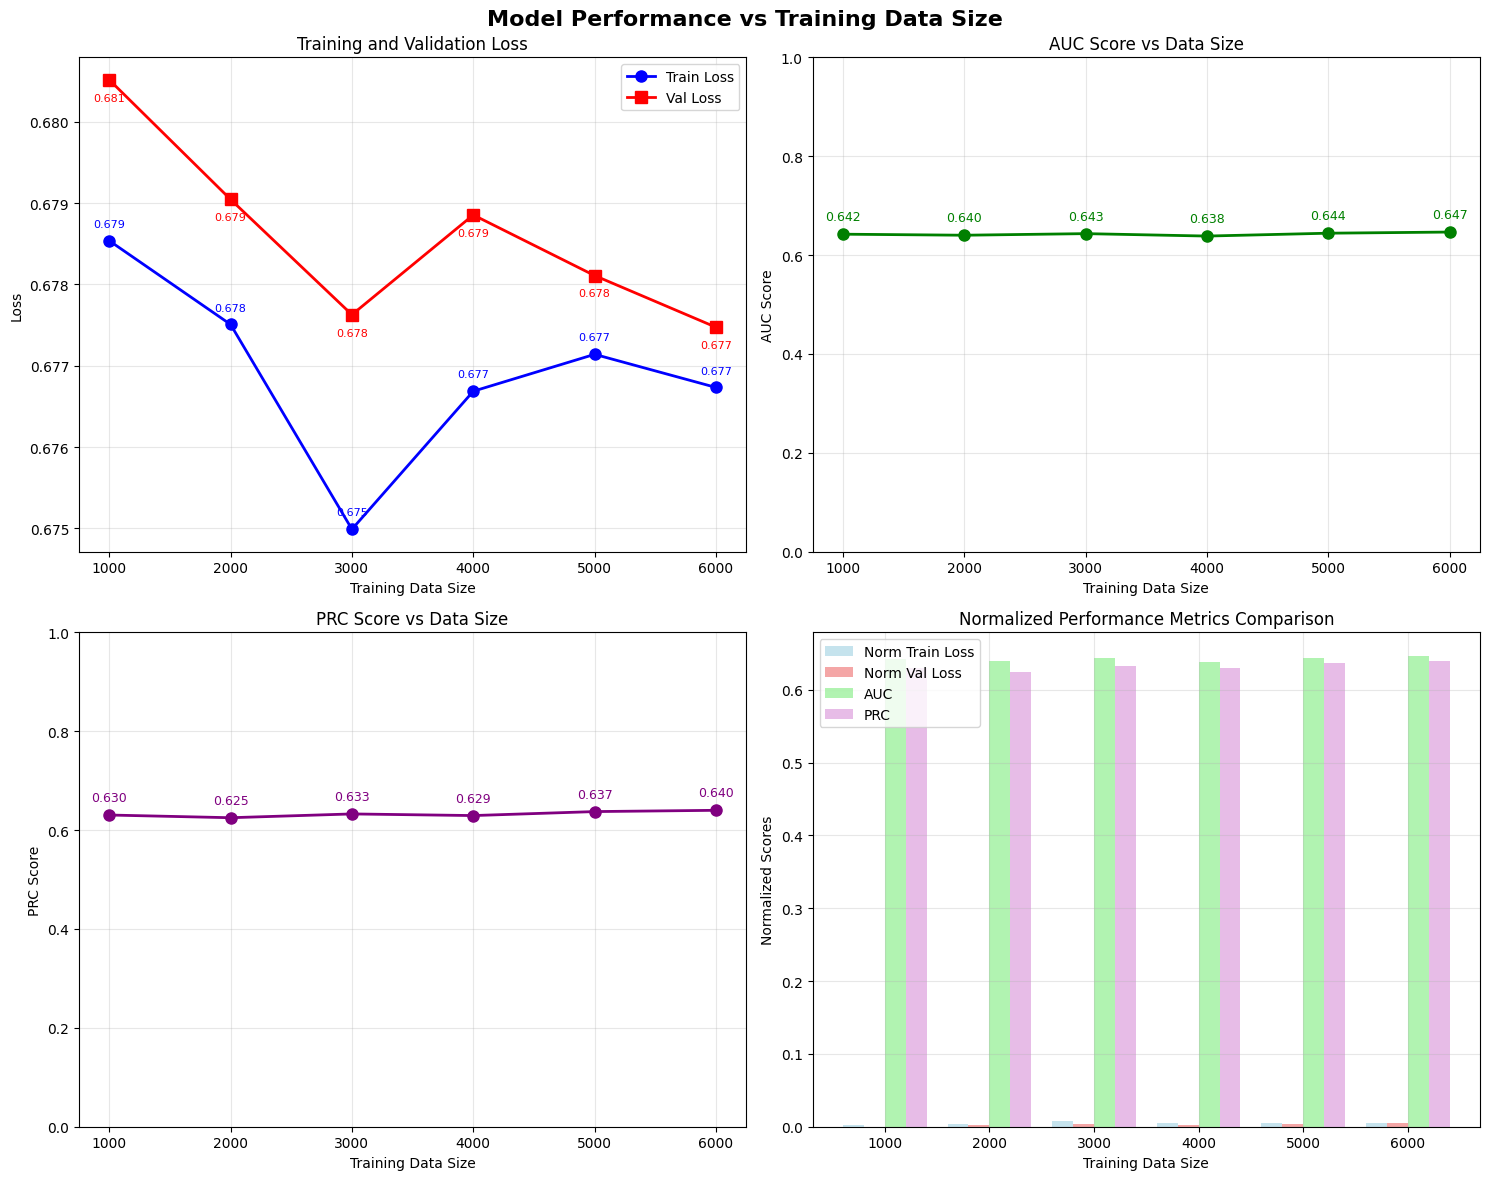

In [16]:

# 绘制图像
plot_training_size_results(results, save_path="")

In [11]:
# sampler
from dgl.dataloading import MultiLayerFullNeighborSampler
from dgl.dataloading.negative_sampler import GlobalUniform, PerSourceUniform
from sampler import HomoGraphDataSampler
# 我不要抽样某部分邻居，我要每一层所有的邻居都要，给我整个子图。
pos_sampler = MultiLayerFullNeighborSampler(model_layers)
# 在整个图里 均匀随机 选 k 个节点，组成负样本,这是u对每个真实边，再造一个假边
neg_sampler = GlobalUniform(k=1)

sampler = HomoGraphDataSampler(g, pos_sampler, neg_sampler)
# 把前面生成正负样本的流程封装起来，生成批次数据集
train_loader = sampler.construct_batch_data_sampler(train_eids, reverse_eids, batch_size=train_batch_size)
test_loader = sampler.construct_batch_data_sampler(test_eids, reverse_eids, batch_size=train_batch_size)

In [13]:
import torch
from tqdm import tqdm
from sampler import HomoGraphDataSampler
from tqdm import tqdm
from train import Trainer
from plot import plot_one_curve

# 假设这里的 g 已经是你之前用的图，并且有 g.edata['sign']（1 正语义, -1 负语义）
# 假设你已经有: GATModel, Trainer, HomoGraphDataSampler, pos_sampler, neg_sampler, reverse_eids, test_loader, plot_one_curve

# ========== 1. 从图中取出正/负语义边 ==========

sign = g.edata["sign"]   # 形状 [num_edges]，值为 {1, -1}

pos_eids_all = (sign == 1).nonzero(as_tuple=True)[0]
neg_eids_all = (sign == -1).nonzero(as_tuple=True)[0]

print(f"Total positive semantic edges: {len(pos_eids_all)}")
print(f"Total negative semantic edges: {len(neg_eids_all)}")

# 保证正负数量平衡，截成一样多
min_num = min(len(pos_eids_all), len(neg_eids_all))
pos_eids_all = pos_eids_all[:min_num]
neg_eids_all = neg_eids_all[:min_num]

print(f"Balanced pool size: {min_num} pos, {min_num} neg (total {2*min_num})")

# ========== 2. 定义不同的训练数据量档位 ==========

# 每个 size 是 "总训练边数"（正+负），必须满足 size/2 <= min_num
data_sizes = [1000, 2000, 5000, 10000]  # 你可以根据 min_num 调整

# 过滤一下，避免超过可用上限
data_sizes = [s for s in data_sizes if s // 2 <= min_num]
print("Will run data sizes:", data_sizes)

# ========== 3. 准备结果记录容器 ==========

all_sizes = []
all_train_loss = []
all_val_loss = []
all_prc = []
all_auc = []

# ========== 4. 逐个数据量跑完整训练过程 ==========

for size in data_sizes:
    print("\n" + "=" * 60)
    print(f"Using {size} edges (pos {size//2}, neg {size//2}) for training")

    n_half = size // 2

    # ---- 4.1 从正负池中随机抽样 ----
    # 注意：每个数据量实验前都重置随机种子，以保证对比公平
    reset_seed(seed)

    perm_pos = torch.randperm(len(pos_eids_all))[:n_half]
    perm_neg = torch.randperm(len(neg_eids_all))[:n_half]

    cur_pos_eids = pos_eids_all[perm_pos]
    cur_neg_eids = neg_eids_all[perm_neg]

    # 合并并打乱（可选）
    cur_train_eids = torch.cat([cur_pos_eids, cur_neg_eids])
    perm_all = torch.randperm(len(cur_train_eids))
    cur_train_eids = cur_train_eids[perm_all].to(device)

    print(f"Actual train edges: {len(cur_train_eids)}")

    # ---- 4.2 用这批 train_eids 构造新的 train_loader ----
    # 这里用你原来的 HomoGraphDataSampler 框架
    sampler = HomoGraphDataSampler(g, pos_sampler, neg_sampler)
    cur_train_loader = sampler.construct_batch_data_sampler(
        cur_train_eids,
        reverse_eids,
        batch_size=train_batch_size
    )

    # ---- 4.3 重新初始化模型和 Trainer（每个 size 都从头训练） ----
    reset_seed(seed)
    model = GATModel(in_feats, h_feats, out_feats, num_heads).to(device)

    trainer = Trainer(
        model,
        nn.BCELoss(),
        lr=initial_lr,
        scheduler_step_size=scheduler_step_size,
        scheduler_gamma=scheduler_gamma,
        threshold=scheduler_threshold
    )

    # ---- 4.4 训练固定轮数，并在同一个 test_loader 上评估 ----
    best_val_auc = 0.0
    size_train_loss = []
    size_val_loss = []
    size_prc = []
    size_auc = []

    for epoch in tqdm(range(num_epochs), desc=f"Size {size}"):
        # 训练一轮
        train_loss, p1, p2, lr = trainer.train_one_epoch(cur_train_loader, device)

        # 验证（test_loader 不变）
        val_loss, prc, auc = trainer.evaluate(test_loader, device)

        size_train_loss.append(train_loss)
        size_val_loss.append(val_loss)
        size_prc.append(prc)
        size_auc.append(auc)

        if auc > best_val_auc:
            best_val_auc = auc

        print(f"[Size {size}] Epoch {epoch+1}/{num_epochs}, "
              f"Lr: {lr:.5f}, Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val PRC: {prc:.4f}, Val AUC: {auc:.4f}")

    # ---- 4.5 记录每个 size 的最终效果（你可以选最后一轮或最佳 AUC） ----
    all_sizes.append(size)
    all_train_loss.append(size_train_loss[-1])   # 最后一轮的 train loss
    all_val_loss.append(size_val_loss[-1])       # 最后一轮的 val loss
    all_prc.append(size_prc[-1])                 # 最后一轮 PRC
    all_auc.append(size_auc[-1])                 # 最后一轮 AUC

    print(f"[Size {size}] Best Val AUC over {num_epochs} epochs: {best_val_auc:.4f}")

# ========== 5. 画“数据量 vs 性能”的曲线 ==========

# 注意：这里用 size 当 x 轴
plot_one_curve(all_train_loss, "Train Loss (last epoch)", "Train Loss vs #Edges", x=all_sizes)
plot_one_curve(all_val_loss,   "Val Loss (last epoch)",   "Val Loss vs #Edges", x=all_sizes)
plot_one_curve(all_prc,        "Val PRC (last epoch)",    "Val PRC vs #Edges",  x=all_sizes)
plot_one_curve(all_auc,        "Val AUC (last epoch)",    "Val AUC vs #Edges",  x=all_sizes)

print("Data sizes:", all_sizes)
print("Final Val AUCs:", all_auc)


Total positive semantic edges: 1383101
Total negative semantic edges: 13722
Balanced pool size: 13722 pos, 13722 neg (total 27444)
Will run data sizes: [1000, 2000, 5000, 10000]

Using 1000 edges (pos 500, neg 500) for training
Actual train edges: 1000


Size 1000:   2%|▏         | 1/45 [00:53<39:27, 53.81s/it]

[Size 1000] Epoch 1/45, Lr: 0.00100, Train Loss: 0.6937, Val Loss: 0.6935, Val PRC: 0.4592, Val AUC: 0.5120


Size 1000:   4%|▍         | 2/45 [01:48<38:57, 54.37s/it]

[Size 1000] Epoch 2/45, Lr: 0.00100, Train Loss: 0.6935, Val Loss: 0.6934, Val PRC: 0.4761, Val AUC: 0.5410


...

[Size 1000] Epoch 18/45, Lr: 0.00070, Train Loss: 0.6931, Val Loss: 0.6931, Val PRC: 0.5279, Val AUC: 0.6030


Size 1000:  42%|████▏     | 19/45 [16:31<22:20, 51.56s/it]

[Size 1000] Epoch 19/45, Lr: 0.00070, Train Loss: 0.6931, Val Loss: 0.6931, Val PRC: 0.5282, Val AUC: 0.6037


Size 1000:  42%|████▏     | 19/45 [16:37<22:44, 52.50s/it]


KeyboardInterrupt: 

In [8]:
# model
reset_seed(seed)

# initial_emb = torch.randn(g.num_nodes(), in_feats) * 0.01  # 模拟初始特征
initial_emb = nn.Parameter(torch.Tensor(g.num_nodes(), in_feats), requires_grad = False)
# 刚才那堆空数字用“Xavier 初始化”的方式随机填上值，不要太大也不要太小的值
nn.init.xavier_uniform_(initial_emb)
g.ndata['feat'] = initial_emb.to(device)
keep_feat = g.ndata['feat']

print(initial_emb)


Parameter containing:
tensor([[ 0.0133,  0.0144, -0.0041,  ..., -0.0059, -0.0062, -0.0168],
        [-0.0099,  0.0043, -0.0023,  ..., -0.0010,  0.0042,  0.0049],
        [-0.0158, -0.0064,  0.0146,  ..., -0.0014, -0.0058, -0.0056],
        ...,
        [ 0.0003, -0.0072, -0.0008,  ...,  0.0080, -0.0031,  0.0123],
        [ 0.0058,  0.0118,  0.0148,  ..., -0.0165,  0.0093,  0.0139],
        [ 0.0089, -0.0036,  0.0088,  ...,  0.0118,  0.0057,  0.0075]])


## Train

In [9]:
from tqdm import tqdm
from train import Trainer
from plot import plot_one_curve

reset_seed(seed)
# m = RGCNModel(in_feats, h_feats, out_feats, num_rels).to(device)
m = GATModel(in_feats, h_feats, out_feats, num_heads).to(device)
# m = HGTModel(in_feats, out_feats, num_heads, head_size, num_ntypes, num_rels).to(device)
# m.print_params()
reset_seed(seed)
trainer = Trainer(m,
                  # g,
                  # train_loader,
                  # test_loader,
                  # nn.BCEWithLogitsLoss(),
                  nn.BCELoss(),

                  lr=initial_lr,
                  scheduler_step_size=scheduler_step_size,
                  scheduler_gamma=scheduler_gamma,
                  threshold=scheduler_threshold)

# 每个 epoch 的验证集 PRC（可能是 PR-AUC 或者 Precision）
prc_list = []
# 每个 epoch 的验证集 ROC-AUC
auc_list = []
train_loss_list = []
val_loss_list = []
for epoch in tqdm(range(num_epochs)):
    # loss,P = train_one_epoch()
    # 对于不变的情况
    loss, p1, p2, lr = trainer.train_one_epoch(train_loader, device)
    print(p1, p2)
    val_loss, prc, auc = trainer.evaluate(test_loader, device)
    prc_list.append(prc)
    auc_list.append(auc)
    train_loss_list.append(loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Lr: {lr:.5f}, Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f} Val prc: {prc:.4f}, Val auc: {auc:.4f}")

plot_one_curve(train_loss_list, "Train Loss", "Train Loss over Epochs")
plot_one_curve(val_loss_list, "Validation Loss", "Validation Loss over Epochs")

# === 绘制验证集 PRC/AUC 曲线 ===
plot_one_curve(prc_list, "Validation PRC", "Validation PRC over Epochs")
plot_one_curve(auc_list, "Validation AUC", "Validation AUC over Epochs")

base_prc_list = prc_list
base_auc_list = auc_list
base_train_loss_list = train_loss_list
base_val_loss_list = val_loss_list
# 我只是想让模型根据这些特征学参数，没想直接改特征本身，看看它是不是还没被动过。
print(torch.equal(keep_feat, g.ndata['feat']))

  0%|          | 0/45 [00:00<?, ?it/s]

0.580846721885526 0.6177726585235325


  2%|▏         | 1/45 [07:01<5:09:12, 421.64s/it]

Epoch 1/45, Lr: 0.00100, Train Loss: 0.6703, Val Loss: 0.6251 Val prc: 0.6266, Val auc: 0.6962
0.7145531988386596 0.7442275969263573


  4%|▍         | 2/45 [14:15<5:07:13, 428.69s/it]

...

Epoch 7/45, Lr: 0.00100, Train Loss: 0.5170, Val Loss: 0.5130 Val prc: 0.8019, Val auc: 0.8220
0.8074697760413695 0.8271473183570514


 18%|█▊        | 8/45 [1:06:28<5:42:35, 555.56s/it]

Epoch 8/45, Lr: 0.00100, Train Loss: 0.5065, Val Loss: 0.5058 Val prc: 0.8107, Val auc: 0.8300


 18%|█▊        | 8/45 [1:07:16<5:11:07, 504.53s/it]


KeyboardInterrupt: 

  0%|          | 0/45 [00:00<?, ?it/s]

0.5827819016251498 0.6161959071169179


  2%|▏         | 1/45 [00:15<11:17, 15.39s/it]

Epoch 1/45, Lr: 0.00100, Train Loss: 0.6706, Val Loss: 0.6288, Val prc: 0.6220, Val auc: 0.6900
0.69306953210298 0.7347929168884284


  4%|▍         | 2/45 [00:30<11:05, 15.48s/it]

...

Epoch 43/45, Lr: 0.00049, Train Loss: 0.3969, Val Loss: 0.3674, Val prc: 0.9129, Val auc: 0.9180
0.8933324479237282 0.9013334692527544


 98%|█████████▊| 44/45 [1:07:30<01:19, 79.75s/it]

Epoch 44/45, Lr: 0.00049, Train Loss: 0.3959, Val Loss: 0.3666, Val prc: 0.9138, Val auc: 0.9183
0.8936164919574484 0.9016657807438958


100%|██████████| 45/45 [1:08:10<00:00, 90.90s/it]

Epoch 45/45, Lr: 0.00034, Train Loss: 0.3952, Val Loss: 0.3641, Val prc: 0.9144, Val auc: 0.9187


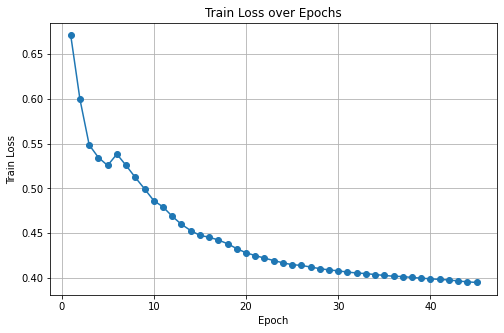

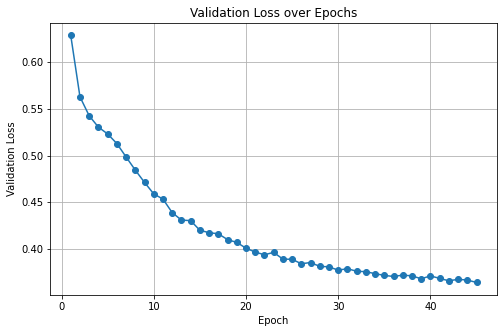

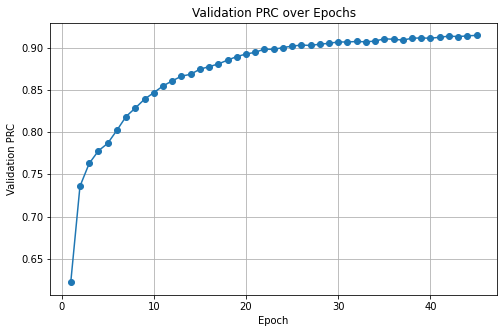

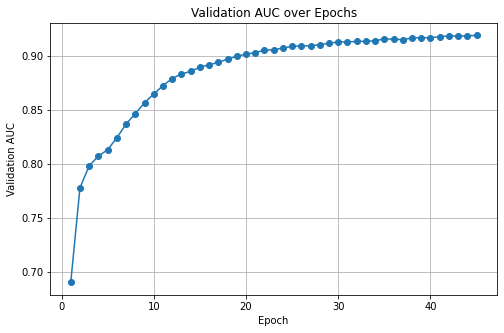

In [10]:
from sampler import  HardNegEdgeSampler, generate_hard_negative_edge_pool_fast

reset_seed(seed)
# m = RGCNModel(in_feats, h_feats, out_feats, num_rels).to(device)
m = GATModel(in_feats, h_feats, out_feats, num_heads).to(device)
# m = HGTModel(in_feats, out_feats, num_heads, head_size, num_ntypes, num_rels).to(device)
# m.print_params()
reset_seed(seed)

trainer = Trainer(m,
                  # g,
                  # train_loader,
                  # test_loader,
                  # nn.BCEWithLogitsLoss(),
                  nn.BCELoss(),

                  lr=initial_lr,
                  scheduler_step_size=scheduler_step_size,
                  scheduler_gamma=scheduler_gamma,
                  threshold=scheduler_threshold)


prc_list = []
auc_list = []
train_loss_list = []
val_loss_list = []
for epoch in tqdm(range(num_epochs)):
    # loss,P = train_one_epoch()
    # 每隔 5 轮，更新一次“难负样本池”
    if epoch % 5 == 0 and epoch >= 5:
        hard_neg_edge_pool = generate_hard_negative_edge_pool_fast(g, m, g.ndata['feat'], train_eids, top_k=3, device=device)

    if epoch >= 5:
        new_neg_sampler = HardNegEdgeSampler(
            neg_sampler,
            hard_neg_edge_pool,
            replace_ratio=0.1,
            )

        new_sampler = HomoGraphDataSampler(g, pos_sampler, new_neg_sampler)
        new_train_loader = new_sampler.construct_batch_data_sampler(train_eids, reverse_eids)
        loss, p1, p2, lr = trainer.train_one_epoch(new_train_loader, device)
    else:
        loss, p1, p2, lr = trainer.train_one_epoch(train_loader, device)
    print(p1, p2)
    val_loss, prc, auc = trainer.evaluate(test_loader, device)
    prc_list.append(prc)
    auc_list.append(auc)
    train_loss_list.append(loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Lr: {lr:.5f}, Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val prc: {prc:.4f}, Val auc: {auc:.4f}")


plot_one_curve(train_loss_list, "Train Loss", "Train Loss over Epochs")
plot_one_curve(val_loss_list, "Validation Loss", "Validation Loss over Epochs")

# === 绘制验证集 PRC/AUC 曲线 ===
plot_one_curve(prc_list, "Validation PRC", "Validation PRC over Epochs")
plot_one_curve(auc_list, "Validation AUC", "Validation AUC over Epochs")

## Compare

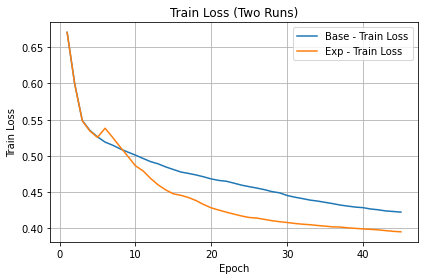

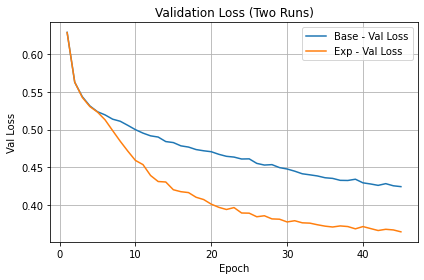

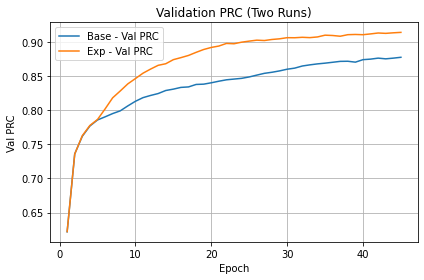

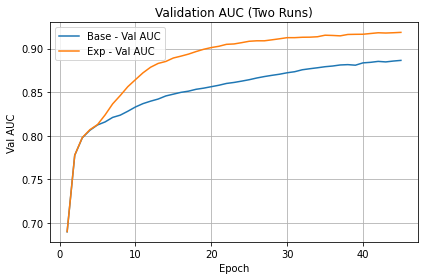

In [11]:
from plot import plot_two_curve

plot_two_curve(base_train_loss_list, train_loss_list,
               "Base - Train Loss", "Exp - Train Loss",
               "Train Loss", "Train Loss (Two Runs)")

plot_two_curve(base_val_loss_list, val_loss_list,
               "Base - Val Loss", "Exp - Val Loss",
               "Val Loss", "Validation Loss"
                           " (Two Runs)")

plot_two_curve(base_prc_list, prc_list,
               "Base - Val PRC", "Exp - Val PRC",
               "Val PRC", "Validation PRC (Two Runs)")

plot_two_curve(base_auc_list, auc_list,
               "Base - Val AUC", "Exp - Val AUC",
               "Val AUC", "Validation AUC (Two Runs)")
